# REidYOLO detection

## Подготовка

### init

In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
import os
from google.colab import userdata

# Получаем учетные данные из менеджера секретов Colab
kaggle_username = userdata.get('KAGGLE_USERNAME')
kaggle_key = userdata.get('KAGGLE_KEY')

# Устанавливаем переменные окружения для Kaggle
os.environ['KAGGLE_USERNAME'] = kaggle_username
os.environ['KAGGLE_KEY'] = kaggle_key
os.environ['KAGGLEHUB_CACHE'] = '/'

# Создаем директорию .kaggle, если ее нет
!mkdir -p ~/.kaggle

# Создаем файл kaggle.json с учетными данными
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')

# Устанавливаем правильные права доступа для файла kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Теперь вы можете использовать kaggle CLI или kagglehub.login()
# kagglehub.login() не всегда нужен, если kaggle.json настроен правильно
print("Kaggle API credentials configured successfully!")

Kaggle API credentials configured successfully!


### Фиксируем сиды

In [2]:
import torch
import numpy as np
import random



_SEED = 9999
random.seed(_SEED)
np.random.seed(_SEED)
torch.manual_seed(_SEED)
torch.cuda.manual_seed(_SEED)

### Загружаем данные

In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
import shutil
from google.colab import drive

# Монтируем Google Drive
drive.mount('/content/drive')

# Пути к файлам на Google Drive
gdrive_path = '/content/drive/MyDrive/KaggleLab'
files_to_copy = ['trn_meta.csv', 'tst_meta.csv']

for f_name in files_to_copy:
    src = os.path.join(gdrive_path, f_name)
    dst = os.path.join('/', f_name)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied {f_name} to {dst}')
    else:
        print(f'Warning: {f_name} not found in {gdrive_path}')

ROOT = kagglehub.competition_download('dl-lab-2-stuff-detection')

print('Data source import complete.')

Mounted at /content/drive
Copied trn_meta.csv to /trn_meta.csv
Copied tst_meta.csv to /tst_meta.csv


100%|██████████| 3.24G/3.24G [00:32<00:00, 107MB/s]

Extracting files...


Data source import complete.


### Mini research

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

META_PATH = '/'

print("META_PATH = ", META_PATH)
print("ROOT = ", ROOT)

META_PATH =  /
ROOT =  /competitions/dl-lab-2-stuff-detection


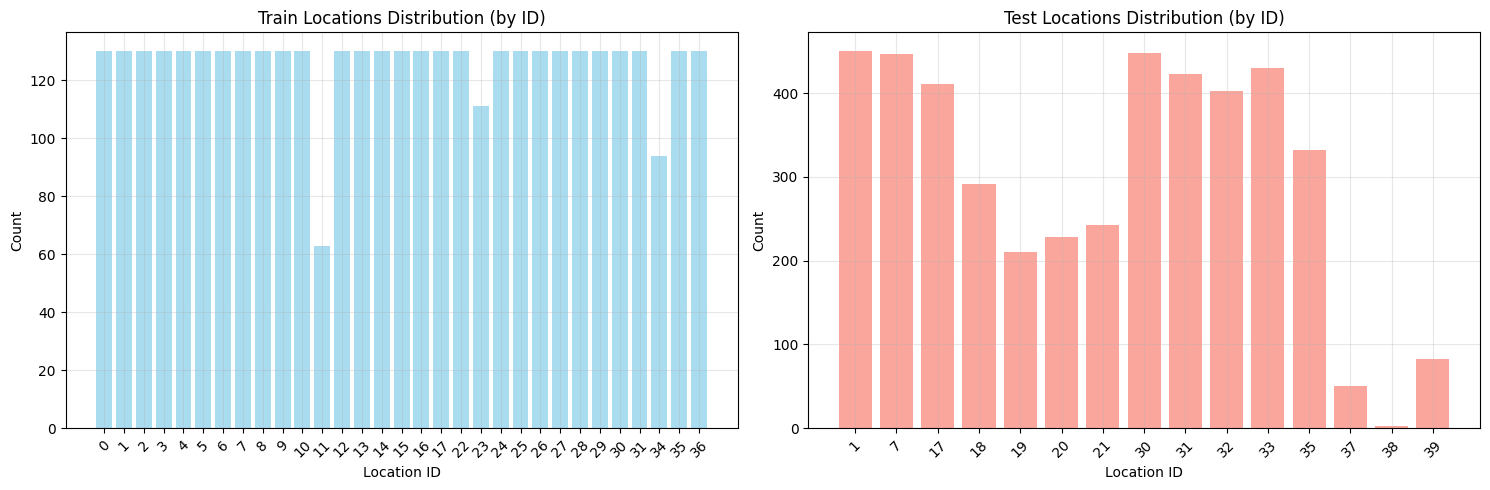

In [6]:
trn_meta = pd.read_csv('/trn_meta.csv')
tst_meta = pd.read_csv('/tst_meta.csv')

# Train loc sizes - sorted by location ID
loc_sizes = (
    trn_meta
    .groupby("loc")
    .size()
    .reset_index(name="count")
    .sort_values("loc")
)

# Test loc sizes - sorted by location ID
tst_loc_sizes = (
    tst_meta
    .groupby("loc")
    .size()
    .reset_index(name="count")
    .sort_values("loc")
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.bar(loc_sizes['loc'].astype(str), loc_sizes['count'], alpha=0.7, color='skyblue')
plt.title('Train Locations Distribution (by ID)')
plt.xlabel('Location ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(tst_loc_sizes['loc'].astype(str), tst_loc_sizes['count'], alpha=0.7, color='salmon')
plt.title('Test Locations Distribution (by ID)')
plt.xlabel('Location ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
from PIL import Image
import os

analyze_df = pd.concat([trn_meta, tst_meta], axis=0)

def get_dims(row):
    # Путь к тренировочным изображениям
    train_path = os.path.join(ROOT, 'yolo_dataset/yolo_dataset/train/images', row['fname'])
    # Путь к тестовым изображениям
    test_path = os.path.join(ROOT, 'test_images/test_images', row['fname'])

    if os.path.exists(train_path):
        img_path = train_path
    elif os.path.exists(test_path):
        img_path = test_path
    else:
        return (None, None)

    try:
        with Image.open(img_path) as img:
            return img.size # (width, height)
    except:
        return (None, None)

analyze_df['dims'] = analyze_df.apply(get_dims, axis=1)
analyze_df.head()

,fname,loc,datetime,dims
0,0209-10_00864300.jpg,7,2025-09-02 12:16:33,"(1280, 720)"
1,0209-10_00864400.jpg,7,2025-09-02 12:16:37,"(1280, 720)"
2,0209-10_00867700.jpg,7,2025-09-02 12:18:49,"(1280, 720)"
3,0209-10_00867800.jpg,7,2025-09-02 12:18:53,"(1280, 720)"
4,0209-10_00870700.jpg,7,2025-09-02 12:20:49,"(1280, 720)"


In [8]:
analyze_df.groupby(['dims']).count()

,fname,loc,datetime
dims,,,
"(1280, 720)",8362,8362,8362


### Разделение на train / val (TODO:  примерно одинаковое соотношение staff / customer в train / val)

In [9]:
import shutil
from pathlib import Path

DATASET_PATH = f"{ROOT}/yolo_dataset/yolo_dataset"

IMAGES_PATH = f"{DATASET_PATH}/train/images"
LABELS_PATH = f"{DATASET_PATH}/train/labels"

META_PATH = "/trn_meta.csv"

trn_meta = pd.read_csv(META_PATH)

print("Total images:", len(trn_meta))
trn_meta.head()

Total images: 3908


,fname,loc,datetime
0,0209-10_00864300.jpg,7,2025-09-02 12:16:33
1,0209-10_00864400.jpg,7,2025-09-02 12:16:37
2,0209-10_00867700.jpg,7,2025-09-02 12:18:49
3,0209-10_00867800.jpg,7,2025-09-02 12:18:53
4,0209-10_00870700.jpg,7,2025-09-02 12:20:49


In [10]:
VAL_RATIO = 0.2

excluded_from_val = [1, 7, 17, 30, 31, 35] # сквозные локации train->test в train

target_val_size = len(trn_meta) * VAL_RATIO

val_locs = []
current = 0

possible_val_locs = loc_sizes[~loc_sizes['loc'].isin(excluded_from_val)]

for _, row in possible_val_locs.sample(frac=1, random_state=42).iterrows():

    if current < target_val_size:
        val_locs.append(row["loc"])
        current += row["count"]

print("VAL locs:", val_locs)
print("VAL size:", current)
print("VAL ratio:", current / len(trn_meta))

VAL locs: [np.int64(10), np.int64(23), np.int64(0), np.int64(34), np.int64(13), np.int64(11), np.int64(15)]
VAL size: 788
VAL ratio: 0.2016376663254862


In [11]:
train_df = trn_meta[~trn_meta["loc"].isin(val_locs)]
val_df = trn_meta[trn_meta["loc"].isin(val_locs)]

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 3120
Val: 788


In [12]:
SPLIT_PATH = f"{ROOT}/yolo_split"

train_img_dir = f"{SPLIT_PATH}/images/train"
val_img_dir = f"{SPLIT_PATH}/images/val"

train_lbl_dir = f"{SPLIT_PATH}/labels/train"
val_lbl_dir = f"{SPLIT_PATH}/labels/val"

for p in [train_img_dir, val_img_dir, train_lbl_dir, val_lbl_dir]:
    os.makedirs(p, exist_ok=True)

In [13]:
def copy_subset(df, img_dst, lbl_dst):

    for _, row in df.iterrows():

        img_name = row["fname"]
        lbl_name = img_name.replace(".jpg", ".txt")

        shutil.copy(
            os.path.join(IMAGES_PATH, img_name),
            os.path.join(img_dst, img_name)
        )

        shutil.copy(
            os.path.join(LABELS_PATH, lbl_name),
            os.path.join(lbl_dst, lbl_name)
        )

In [14]:
copy_subset(train_df, train_img_dir, train_lbl_dir)
copy_subset(val_df, val_img_dir, val_lbl_dir)

print("Split completed")
print("Train images:", len(os.listdir(train_img_dir)))
print("Val images:", len(os.listdir(val_img_dir)))

Split completed
Train images: 3120
Val images: 788


In [15]:
yaml_text = f"""
path: {SPLIT_PATH}

train: images/train
val: images/val

names:
  0: customer
  1: staff
"""

with open(f"{SPLIT_PATH}/dataset.yaml", "w") as f:
    f.write(yaml_text)

print("dataset.yaml created")

dataset.yaml created


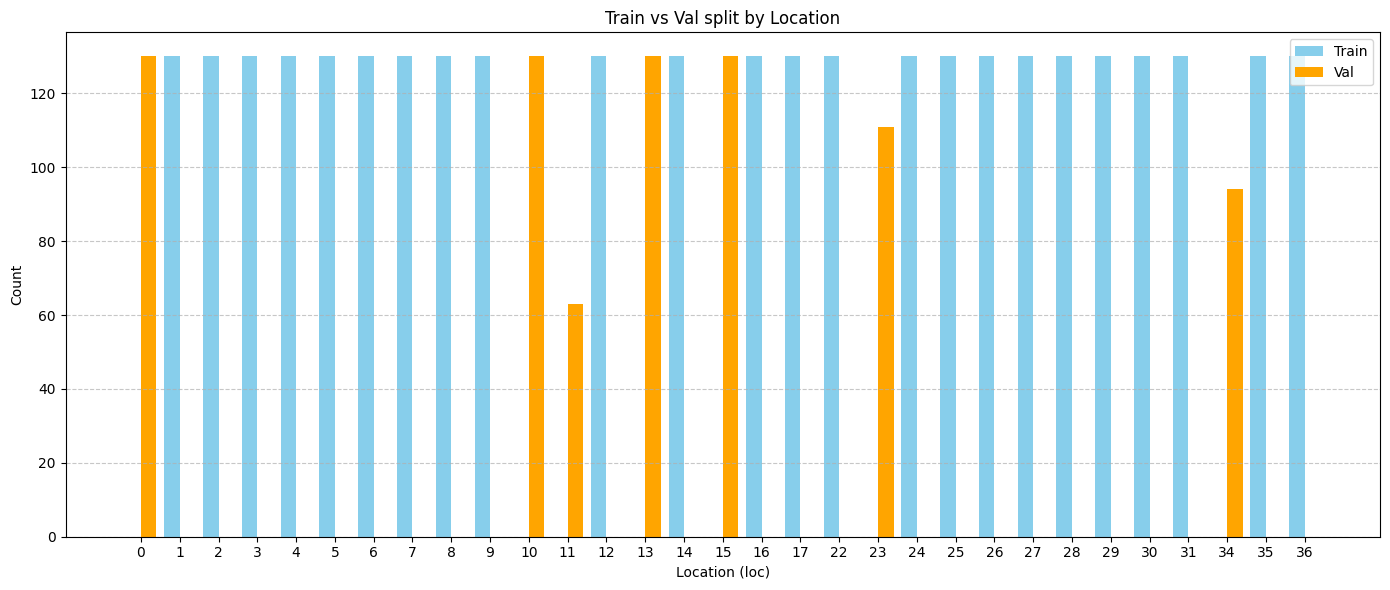

In [16]:
train_counts = train_df.groupby('loc').size().reset_index(name='train')
val_counts = val_df.groupby('loc').size().reset_index(name='val')

combined = pd.merge(train_counts, val_counts, on='loc', how='outer').fillna(0)
combined = combined.sort_values('loc')

plt.figure(figsize=(14, 6))
x = np.arange(len(combined['loc']))
width = 0.4

plt.bar(x - width/2, combined['train'], width, label='Train', color='skyblue')
plt.bar(x + width/2, combined['val'], width, label='Val', color='orange')

plt.xlabel('Location (loc)')
plt.ylabel('Count')
plt.title('Train vs Val split by Location')
plt.xticks(x, combined['loc'].astype(int))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Анализ временных интервалов

In [17]:
trn_meta["datetime"] = pd.to_datetime(trn_meta["datetime"])

trn_meta = trn_meta.sort_values(["loc", "datetime"])

trn_meta["time_diff"] = (
    trn_meta
    .groupby("loc")["datetime"]
    .diff()
    .dt.total_seconds()
)

trn_meta["time_diff"] = trn_meta["time_diff"].fillna(0)

trn_meta.head()

,fname,loc,datetime,time_diff
1040,0209-18_00869100.jpg,0,2025-09-02 13:54:45,0.0
1041,0209-18_00869300.jpg,0,2025-09-02 13:54:52,7.0
1042,0209-18_00871200.jpg,0,2025-09-02 13:56:20,88.0
1043,0209-18_00871500.jpg,0,2025-09-02 13:56:33,13.0
1044,0209-18_00872700.jpg,0,2025-09-02 13:57:44,71.0


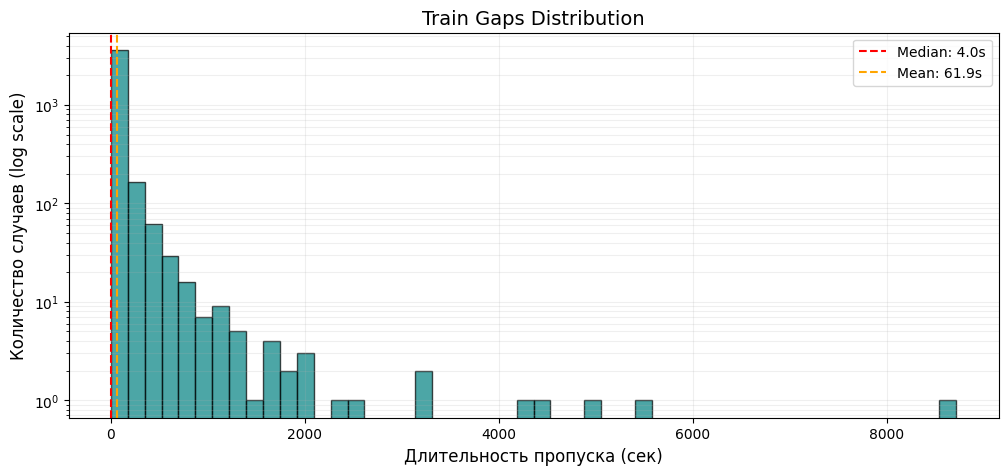

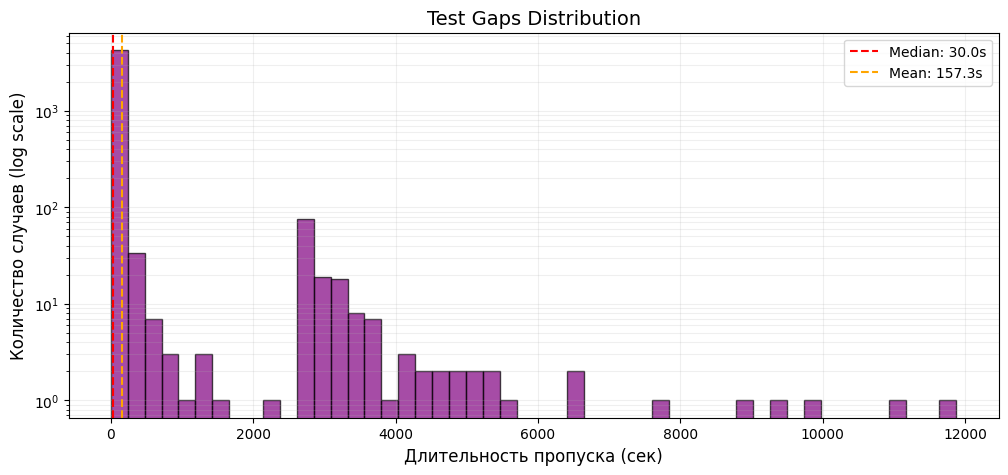

In [19]:
import seaborn as sns

trn_meta['datetime'] = pd.to_datetime(trn_meta['datetime'])
trn_meta = trn_meta.sort_values(['loc', 'datetime'])
trn_meta['time_diff'] = trn_meta.groupby('loc')['datetime'].diff().dt.total_seconds().fillna(0)

tst_meta['datetime'] = pd.to_datetime(tst_meta['datetime'])
tst_meta = tst_meta.sort_values(['loc', 'datetime'])
tst_meta['time_diff'] = tst_meta.groupby('loc')['datetime'].diff().dt.total_seconds().fillna(0)

def plot_dist(df, title, color):
    plt.figure(figsize=(12, 5))
    data = df['time_diff']

    if len(data) > 0:
        median_val = data.median()
        mean_val = data.mean()

        plt.hist(data, bins=50, color=color, edgecolor='black', alpha=0.7)
        plt.yscale('log')
        plt.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.1f}s')
        plt.axvline(mean_val, color='orange', linestyle='--', label=f'Mean: {mean_val:.1f}s')

    plt.title(title, fontsize=14)
    plt.xlabel('Длительность пропуска (сек)', fontsize=12)
    plt.ylabel('Количество случаев (log scale)', fontsize=12)
    plt.legend()
    plt.grid(True, which='both', ls='-', alpha=0.2)
    plt.show()

plot_dist(trn_meta, 'Train Gaps Distribution', 'teal')
plot_dist(tst_meta, 'Test Gaps Distribution', 'purple')

In [20]:
stats_data = {
    'Dataset': ['TRAIN', 'TEST'],
    'Median Gap (s)': [trn_meta['time_diff'].median(), tst_meta['time_diff'].median()],
    'Std Dev (s)': [trn_meta['time_diff'].std(), tst_meta['time_diff'].std()],
    'Ratio > 20s': [
        len(trn_meta[trn_meta['time_diff'] > 20]) / len(trn_meta),
        len(tst_meta[tst_meta['time_diff'] > 20]) / len(tst_meta)
    ]
}


pd.DataFrame(stats_data)

,Dataset,Median Gap (s),Std Dev (s),Ratio > 20s
0,TRAIN,4.0,272.814011,0.254862
1,TEST,30.0,677.031834,0.992366


Temporal модели, к сожалению, практически не применимы из-за больших временнных интервалов между кадрами и их неравномерности на тестовой выборке

In [ ]:
SPLIT_PATH = Path(ROOT) / "yolo_split"

TRAIN_IMG_DIR = SPLIT_PATH / "images" / "train"
VAL_IMG_DIR = SPLIT_PATH / "images" / "val"

TRAIN_LBL_DIR = SPLIT_PATH / "labels" / "train"
VAL_LBL_DIR = SPLIT_PATH / "labels" / "val"

## Обучение

### Модель (TODO: аугментации)

In [ ]:
!pip install -q ultralytics

In [ ]:
from ultralytics import YOLO
import os


data_yaml_path = f"{SPLIT_PATH}/dataset.yaml"
save_dir = "/content/drive/MyDrive/KaggleLab/weights"
os.makedirs(save_dir, exist_ok=True)

model = YOLO("yolo26x.pt")

results = model.train(
    data=data_yaml_path,
    epochs=50,
    batch=8,
    imgsz=640,
    workers=2,
    device=0,
    cache=True,
    optimizer='AdamW',
    lr0=0.001,
    patience=15,
    seed=42
)

best_weights = os.path.join("runs/detect", "baseline_augmented", "weights", "best.pt")
if os.path.exists(best_weights):
    shutil.copy(best_weights, os.path.join(save_dir, "yolo12m_best_augmented.pt"))
    print(f"Best weights saved to Drive: {save_dir}/yolo12m_best_augmented.pt")

In [ ]:
results.results_dict['metrics/mAP50-95(B)']

### Пути

In [ ]:
model_path = "/content/runs/detect/runs/detect/baseline_augmented/weights/best.pt"
test_images_dir = Path(ROOT) / "test_images" / "test_images"
meta_test_path = "/tst_meta.csv"
sample_sub_path = "/competitions/dl-lab-2-stuff-detection/sample_sub.csv"

preds_labels_dir = Path("/kaggle/working/runs/detect/track_test/labels")
preds_labels_dir.mkdir(parents=True, exist_ok=True)

meta_test = pd.read_csv(meta_test_path)
meta_test["datetime"] = pd.to_datetime(meta_test["datetime"])
grouped = meta_test.groupby("loc")

## Инференс

### configs

In [ ]:
from tqdm import tqdm
import cv2

model = YOLO(best_weights)
TEST_IMAGES = test_images_dir # совместимость
SAMPLE_SUB_PATH = ROOT / 'sample_submission.csv'
CONF_THRES = 0.25
STAFF_SCORE_THRES = 0.4

### Функции для инеференса (TODO: оптимизировать, отключить градиенты)

In [ ]:
def detect(frame):
    result = model(frame, conf=CONF_THRES, verbose=False)[0]

    if result.boxes is None or len(result.boxes) == 0:
        return None

    return np.concatenate(
        [
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.conf.cpu().numpy()[:, None],
            result.boxes.cls.cpu().numpy()[:, None],
        ],
        axis=1,
    )

def save_predictions_to_csv(predictions_dict, output_path):
    rows = []
    for idx, (fname, boxes) in enumerate(predictions_dict.items()):
        rows.append({
            'id': idx,
            'image_name': fname,
            'boxes': json.dumps(boxes, separators=(",", ":")) if boxes else "[]"
        })

    df = pd.DataFrame(rows, columns=['id', 'image_name', 'boxes'])
    df.to_csv(output_path, index=False)
    print(f" Предсказания сохранены: {output_path} ({len(df)} записей)")

def load_predictions_from_csv(csv_path):
    df = pd.read_csv(csv_path)
    predictions = {}
    for _, row in df.iterrows():
        fname = row['image_name']
        boxes = json.loads(row['boxes']) if row['boxes'] != '[]' else []
        predictions[fname] = boxes
    print(f" Загружено {len(predictions)} предсказаний из: {csv_path}")
    return predictions

### runs_no_track (TODO: TTA?)

In [ ]:
def run_no_track():
    results = {}

    for _, row in tqdm(meta_test.iterrows(), total=len(meta_test), desc="No Track"):
        img_path = TEST_IMAGES / row["fname"]
        frame = cv2.imread(str(img_path))

        if frame is None:
            results[row["fname"]] = []
            continue

        dets = detect(frame)

        h, w = frame.shape[:2]
        boxes = []

        if dets is not None:
            for d in dets:
                x1, y1, x2, y2, score, cls = d

                if int(cls) == 1 and score > STAFF_SCORE_THRES:
                    xc = ((x1 + x2) / 2) / w
                    yc = ((y1 + y2) / 2) / h
                    bw = (x2 - x1) / w
                    bh = (y2 - y1) / h

                    boxes.append([float(xc), float(yc), float(bw), float(bh), float(score)])

        results[row["fname"]] = boxes

    return results

no_track_results = run_no_track()

save_predictions_to_csv(no_track_results, 'submission_no_track.csv')
print(f" Найдено объектов: {sum(len(v) for v in no_track_results.values())}")


### REID

Идея: чем чаще встречается, тем вероятнее staff. Но доверяем больше YOLO

#### REID configs
##### Параметры детекции YOLO
- `CONF_THRES = 0.25` - **минимальная уверенность** детекции YOLO (ниже - игнорируем)
- `STAFF_SCORE_THRES = 0.4` - **порог голосования**: если staff с score > 0.4, считаем голосом
- `CUSTOMER_STRONG_THRES = 0.85` - **защита от ложных апгрейдов**: customer с score > 0.85 не трогаем

##### Параметры трекера BotSort
- `track_high_thresh = 0.3` - **создание трека**: детекции > 0.3 сразу начинают новый трек
- `track_low_thresh = 0.25` - **продолжение трека**: детекции 0.25-0.3 могут присоединиться к существующему
- `new_track_thresh = 0.4` - **инициализация**: новый трек при несоответствии существующим
- `match_thresh = 0.7` - **сопоставление**: порог сходства для связи детекции с треком
- `track_buffer = 300` - **память**: сколько кадров хранить трек без обновлений

##### Параметры голосования
- `TRACK_MIN_FRAMES = 15` - **минимальная длина** трека для анализа
- `STAFF_VOTES_NEEDED = 8` - **нужно голосов** для апгрейда до staff
- `MIN_RATIO = 8/15 ≈ 0.53` - **минимальная доля** staff-детекций в треке

In [ ]:
!pip install boxmot
from boxmot import BotSort

In [ ]:
CONF_THRES = 0.25
STAFF_SCORE_THRES = 0.4
TRACK_MIN_FRAMES = 15
STAFF_VOTES_NEEDED = 8
CUSTOMER_STRONG_THRES = 0.85

### REID run function

In [ ]:
def run_reid_voting():
    results = {}
    device = 0 if torch.cuda.is_available() else "cpu"

    MIN_RATIO = STAFF_VOTES_NEEDED / TRACK_MIN_FRAMES

    locations = meta_test["loc"].unique()
    print(f"Всего локаций для обработки: {len(locations)}")

    for loc_idx, (loc, group) in enumerate(tqdm(meta_test.groupby("loc"), desc="REID + Voting")):
        print(f"\nЛокация {loc_idx+1}/{len(locations)}: {loc}")

        group = group.sort_values("datetime")

        tracker = BotSort(
            reid_weights="osnet_x0_25_msmt17.pt",
            device=device,
            half=True,
            track_high_thresh=0.3,
            track_low_thresh=0.25,
            new_track_thresh=0.4,
            match_thresh=0.7,
            track_buffer=300
        )

        track_info = {}
        frame_index = {}

        #  Сохраняем оригинальные классы YOLO для каждого детекта
        yolo_original_cls = {}  # {(fname, bbox_tuple): cls}

        total_detections = 0
        total_tracks_created = 0

        # 1: Сбор статистики + сохранение оригинальных классов
        for frame_idx, (_, row) in enumerate(group.iterrows()):
            if frame_idx % 50 == 0:
                print(f"Обработано кадров: {frame_idx}/{len(group)}", end='\r')

            img_path = TEST_IMAGES / row["fname"]
            frame = cv2.imread(str(img_path))
            if frame is None:
                continue

            dets = detect(frame)
            if dets is None:
                dets = np.empty((0, 6))

            # Сохраняем оригинальные классы YOLO ДО трекинга
            for d in dets:
                x1, y1, x2, y2, score, cls = d
                bbox_key = (row["fname"], round(x1, 1), round(y1, 1), round(x2, 1), round(y2, 1))
                yolo_original_cls[bbox_key] = int(cls)

            tracks = tracker.update(dets, frame)
            if tracks is None:
                continue

            for t in tracks:
                track_id = int(t[4])
                score = float(t[5])
                tracker_cls = int(t[6])  # Это класс от трекера, может отличаться от YOLO

                if track_id not in track_info:
                    track_info[track_id] = {
                        "frames": [],
                        "staff_votes": 0,
                        "force_staff": False,
                        "has_yolo_staff": False  # Флаг: был ли staff от YOLO в этом треке
                    }
                    total_tracks_created += 1

                # Находим оригинальный класс YOLO для этого бокса
                x1, y1, x2, y2 = t[:4]
                bbox_key = (row["fname"], round(x1, 1), round(y1, 1), round(x2, 1), round(y2, 1))
                original_cls = yolo_original_cls.get(bbox_key, tracker_cls)  # fallback к трекеру

                track_info[track_id]["frames"].append({
                    "frame": row["fname"],
                    "bbox": t[:4],
                    "score": score,
                    "original_cls": original_cls,  # Используем оригинальный класс YOLO!
                    "tracker_cls": tracker_cls,    # На всякий случай
                    "shape": frame.shape[:2]
                })

                frame_index.setdefault(row["fname"], []).append(
                    (track_id, len(track_info[track_id]["frames"]) - 1)
                )

                # Считаем голоса по оригинальному классу YOLO
                if original_cls == 1 and score > STAFF_SCORE_THRES:
                    track_info[track_id]["staff_votes"] += 1
                    track_info[track_id]["has_yolo_staff"] = True
                    total_detections += 1

        print(f"\nСтатистика локации {loc}:")
        print(f"  Всего треков: {len(track_info)}")
        print(f"  Staff детекций (YOLO): {total_detections}")

        # 2: Определяем принудительные staff треки
        confirmed_tracks = 0
        for track_id, info in track_info.items():
            frames_count = len(info["frames"])
            if frames_count == 0:
                continue

            staff_ratio = info["staff_votes"] / frames_count if frames_count > 0 else 0

            if frames_count >= TRACK_MIN_FRAMES and staff_ratio >= MIN_RATIO:
                info["force_staff"] = True
                confirmed_tracks += 1

        print(f"Подтверждено треков: {confirmed_tracks}/{len(track_info)}")

        # 3: Сбор результатов (только чистые апгрейды)
        upgraded_count = 0

        for _, row in group.iterrows():
            boxes = []

            if row["fname"] in frame_index:
                for track_id, idx in frame_index[row["fname"]]:
                    info = track_info[track_id]
                    f = info["frames"][idx]

                    #  Используем original_cls от YOLO
                    if f["original_cls"] == 1:
                        continue

                    # Только customer от YOLO может быть апгрейднут
                    elif f["original_cls"] == 0:
                        if f["score"] > CUSTOMER_STRONG_THRES: # Уверенный customer - не апгрейдим
                            continue

                        if info["force_staff"]:
                            x1, y1, x2, y2 = f["bbox"]
                            h, w = f["shape"]
                            xc = ((x1 + x2) / 2) / w
                            yc = ((y1 + y2) / 2) / h
                            bw = (x2 - x1) / w
                            bh = (y2 - y1) / h
                            boxes.append([float(xc), float(yc), float(bw), float(bh), float(f["score"])])
                            upgraded_count += 1

            results[row["fname"]] = boxes

        print(f"  Апгрейднуто customer→staff: {upgraded_count}\n")

    total_staff = sum(len(v) for v in results.values())
    print(f"\nИТОГОВАЯ СТАТИСТИКА:")
    print(f"  Всего апгрейдов: {total_staff}\n")

    return results


print("ЗАПУСК INFERENCE С REID И ГОЛОСОВАНИЕМ")
reid_results = run_reid_voting()

save_predictions_to_csv(reid_results, 'submission_reid_voting.csv')
print(f"Найдено апгрейдов: {sum(len(v) for v in reid_results.values())}")

### Объединение staff от YOLO + staff от REID с типа NMS

In [ ]:
def combine_predictions(
    no_track_csv: str,
    reid_csv: str,
    sample_submission_csv: str,
    output_csv: str = 'submission_combined.csv',
    iou_threshold: float = 0.5
):
    print(" Загрузка CSV файлов...")

    df_no = pd.read_csv(no_track_csv)
    df_reid = pd.read_csv(reid_csv)
    df_sample = pd.read_csv(sample_submission_csv)

    no_dict = {
        row['image_name']: json.loads(row['boxes']) if row['boxes'] != '[]' else []
        for _, row in df_no.iterrows()
    }

    reid_dict = {
        row['image_name']: json.loads(row['boxes']) if row['boxes'] != '[]' else []
        for _, row in df_reid.iterrows()
    }

    def calculate_iou(box1, box2):
        xc1, yc1, w1, h1, _ = box1
        xc2, yc2, w2, h2, _ = box2

        x1_1, y1_1 = (xc1 - w1/2), (yc1 - h1/2)
        x2_1, y2_1 = (xc1 + w1/2), (yc1 + h1/2)
        x1_2, y1_2 = (xc2 - w2/2), (yc2 - h2/2)
        x2_2, y2_2 = (xc2 + w2/2), (yc2 + h2/2)

        x1 = max(x1_1, x1_2)
        y1 = max(y1_1, y1_2)
        x2 = min(x2_1, x2_2)
        y2 = min(y2_1, y2_2)

        intersection = max(0, x2 - x1) * max(0, y2 - y1)
        area1 = w1 * h1
        area2 = w2 * h2
        union = area1 + area2 - intersection

        return intersection / union if union > 0 else 0

    def remove_duplicates(boxes_list, iou_thresh=0.5):
        if len(boxes_list) <= 1:
            return boxes_list

        keep = []
        for i, box in enumerate(boxes_list):
            is_duplicate = False
            for kept_box in keep:
                if calculate_iou(box, kept_box) > iou_thresh:
                    is_duplicate = True
                    break
            if not is_duplicate:
                keep.append(box)

        return keep

    combined_rows = []
    total_boxes = 0
    total_removed_duplicates = 0

    for idx, row in df_sample.iterrows():
        img_name = row['image_name']

        no_boxes = no_dict.get(img_name, [])
        reid_boxes = reid_dict.get(img_name, [])

        # Объединение
        all_boxes = no_boxes + reid_boxes
        original_count = len(all_boxes)
        # типа NMS
        all_boxes = remove_duplicates(all_boxes, iou_threshold)
        duplicates_removed = original_count - len(all_boxes)

        if duplicates_removed > 0:
            total_removed_duplicates += duplicates_removed

        combined_rows.append({
            'id': idx,
            'image_name': img_name,
            'boxes': json.dumps(all_boxes, separators=(",", ":")) if all_boxes else "[]"
        })

        total_boxes += len(all_boxes)

    df_combined = pd.DataFrame(combined_rows, columns=['id', 'image_name', 'boxes'])
    df_combined.to_csv(output_csv, index=False)

    print(f"\n Сохранено: {output_csv}")
    print(f" Всего боксов: {total_boxes}")
    print(f" Удалено дубликатов: {total_removed_duplicates}")

    return df_combined

In [ ]:
df_combined = combine_predictions(
    no_track_csv='submission_no_track.csv',
    reid_csv='submission_reid_voting.csv',
    output_csv='/content/submission_combined.csv',
    sample_submission_csv='/competitions/dl-lab-2-stuff-detection/sample_sub.csv'
)

### Сохраняем все измененные REID customer -> staff

In [ ]:
from datetime import datetime


def visualize_and_save_to_drive(
    no_track_path='submission_no_track.csv',
    combined_path='submission_combined.csv',
    test_images_dir=TEST_IMAGES,
    output_root='reid_checking',
    gdrive_base_path='/content/drive/MyDrive/KaggleLab',
    n_limit=200
):
    output_root = Path(output_root)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = output_root / f"comparison_{timestamp}"
    save_dir.mkdir(parents=True, exist_ok=True)

    df_no = pd.read_csv(no_track_path)
    df_combined = pd.read_csv(combined_path)

    diff_frames = []
    for _, row_no in df_no.iterrows():
        img_name = row_no['image_name']
        row_comb = df_combined[df_combined['image_name'] == img_name].iloc[0]

        boxes_no = json.loads(row_no['boxes'])
        boxes_comb = json.loads(row_comb['boxes'])

        if len(boxes_comb) > len(boxes_no):
            diff_frames.append({
                'name': img_name,
                'no': boxes_no,
                'comb': boxes_comb
            })

    print(f"Найдено {len(diff_frames)} измененных кадров")

    def draw(img, boxes, color):
        h, w = img.shape[:2]
        for b in boxes:
            xc, yc, bw, bh, conf = b
            x1, y1 = int((xc - bw/2) * w), int((yc - bh/2) * h)
            x2, y2 = int((xc + bw/2) * w), int((yc + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
        return img


    for i, frame in enumerate(diff_frames[:n_limit]):
        img = cv2.imread(str(Path(test_images_dir) / frame['name']))
        if img is None: continue

        img_no = draw(img.copy(), frame['no'], (0, 0, 255))
        img_comb = draw(img.copy(), frame['comb'], (0, 255, 0))

        fig, ax = plt.subplots(1, 2, figsize=(16, 8))
        ax[0].imshow(cv2.cvtColor(img_no, cv2.COLOR_BGR2RGB))
        ax[0].set_title(f"YOLO Only: {len(frame['no'])}", fontsize=14, pad=10)
        ax[0].axis('off')

        ax[1].imshow(cv2.cvtColor(img_comb, cv2.COLOR_BGR2RGB))
        ax[1].set_title(f"Combined (REID): {len(frame['comb'])}", fontsize=14, pad=10)
        ax[1].axis('off')

        plt.suptitle(f"Frame: {frame['name']}", fontsize=16)
        plt.tight_layout()

        plt.savefig(save_dir / f"{frame['name']}_comp.png", bbox_inches='tight', dpi=100)
        plt.close()

    gdrive_dest = Path(gdrive_base_path) / f"reid_results_{timestamp}"
    shutil.copytree(save_dir, gdrive_dest, dirs_exist_ok=True)
    shutil.copy(combined_path, gdrive_dest / "submission_combined.csv")

    print(f" Картинки сохранены в Drive: {gdrive_dest}")

In [ ]:
visualize_and_save_to_drive()